In [85]:
import pandas as pd
df=pd.read_csv("student_habits_performance.csv")


In [5]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [8]:
df.shape

(1000, 16)

In [10]:
df.head(2)  

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
sns.set(style="whitegrid")

In [17]:
df.isna().sum().sum()

91

In [20]:
df=df.dropna()

In [21]:
df.isna().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

In [23]:
df.duplicated().sum()

0

In [24]:
import warnings
warnings.filterwarnings("ignore")

In [27]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000
mean,20.475248,3.538724,2.504620,1.830363,83.880308,6.474037,3.051705,5.466447,69.558196
std,2.302721,1.469730,1.164802,1.071251,9.453622,1.218943,2.035632,2.857525,16.929436
min,17.000000,0.000000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.000000,2.500000,1.700000,1.000000,77.500000,5.600000,1.000000,3.000000,58.400000
50%,20.000000,3.500000,2.500000,1.800000,84.200000,6.500000,3.000000,5.000000,70.400000
75%,22.000000,4.500000,3.300000,2.600000,90.700000,7.300000,5.000000,8.000000,81.300000
max,24.000000,8.300000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [34]:
df.describe(include="object").columns

Index(['student_id', 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation'],
      dtype='object')

In [45]:
categorical_cols=["gender","part_time_job","diet_quality","parental_education_level","internet_quality","extracurricular_participation"]

In [46]:
for col in categorical_cols:
    print(f"Value counts for {col}: \n {df[col].value_counts()}")

Value counts for gender: 
 gender
Male      440
Female    433
Other      36
Name: count, dtype: int64
Value counts for part_time_job: 
 part_time_job
No     713
Yes    196
Name: count, dtype: int64
Value counts for diet_quality: 
 diet_quality
Fair    396
Good    347
Poor    166
Name: count, dtype: int64
Value counts for parental_education_level: 
 parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64
Value counts for internet_quality: 
 internet_quality
Good       410
Average    352
Poor       147
Name: count, dtype: int64
Value counts for extracurricular_participation: 
 extracurricular_participation
No     620
Yes    289
Name: count, dtype: int64


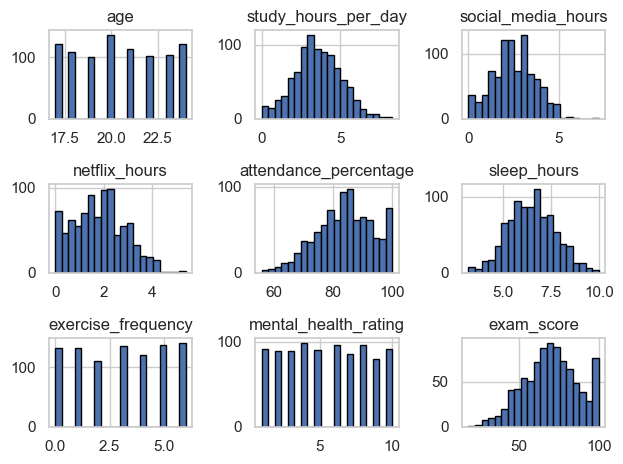

In [48]:
df.hist(bins=20, edgecolor="black")
plt.tight_layout()
plt.show()

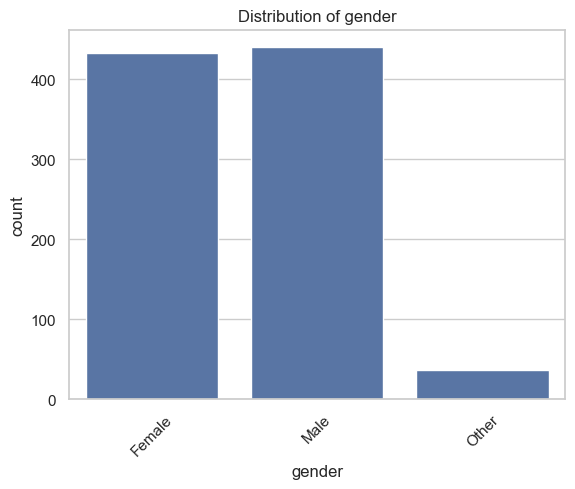

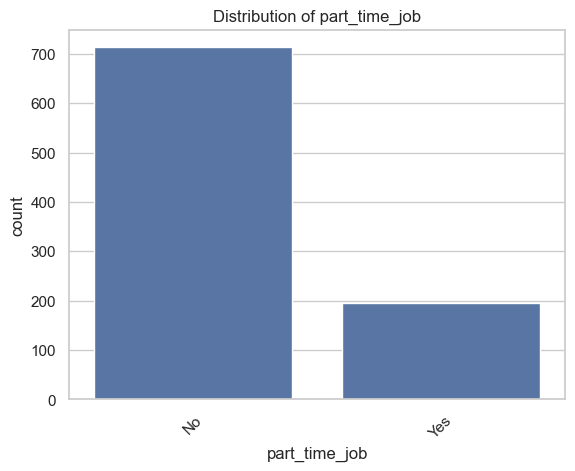

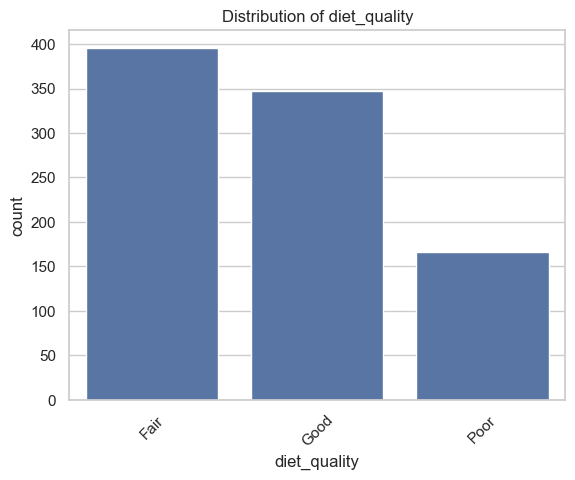

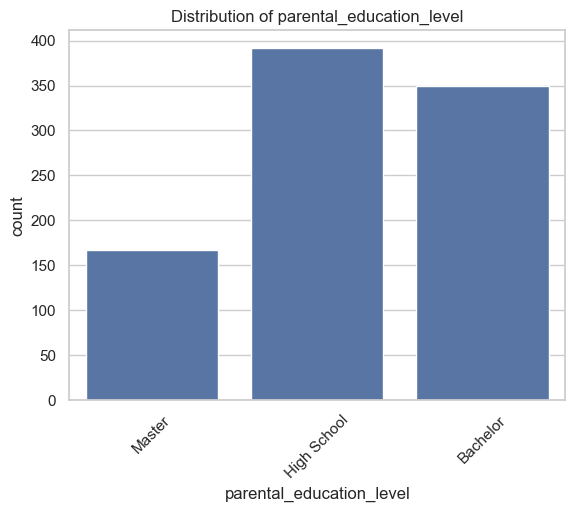

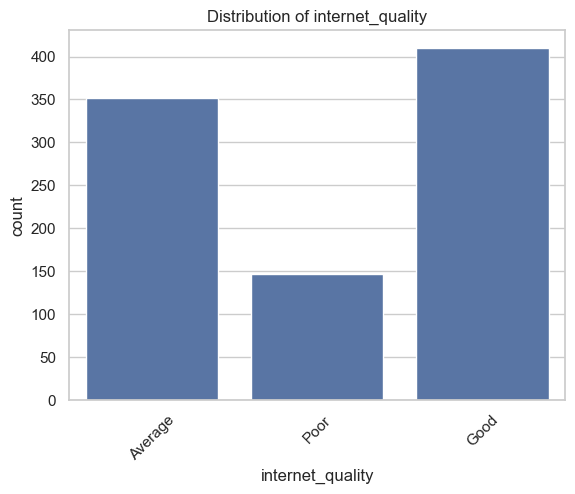

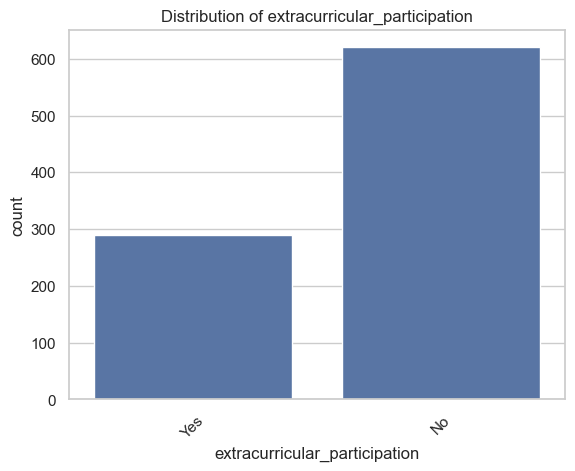

In [49]:
for col in categorical_cols:
    sns.countplot(data=df,x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

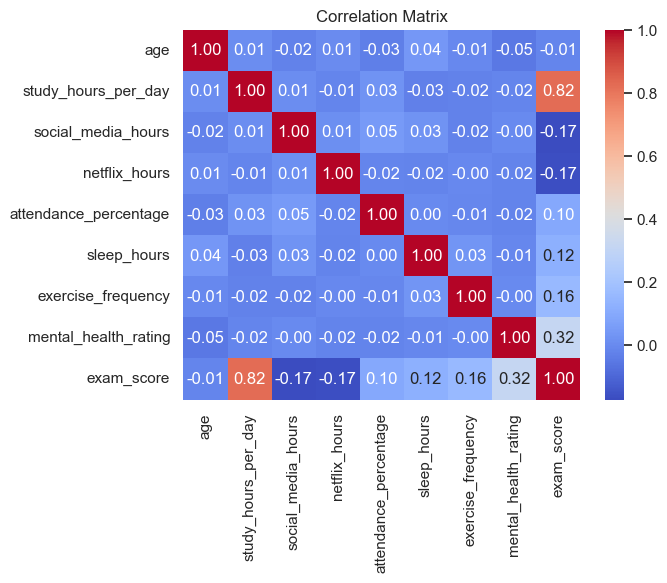

In [52]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [54]:
df.describe().columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')

In [56]:
num_features=['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating']

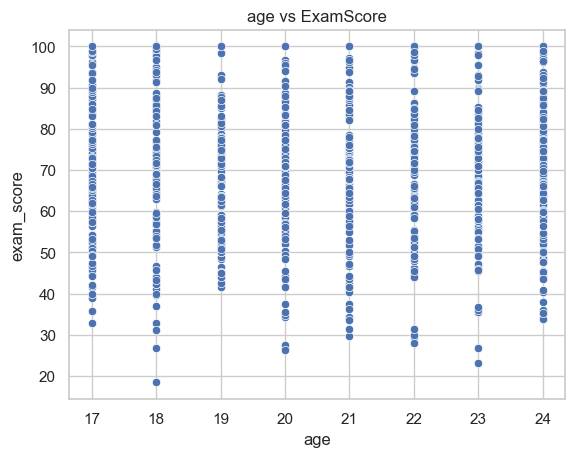

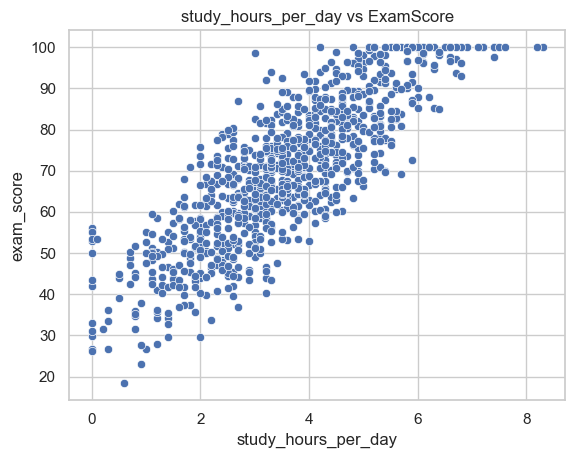

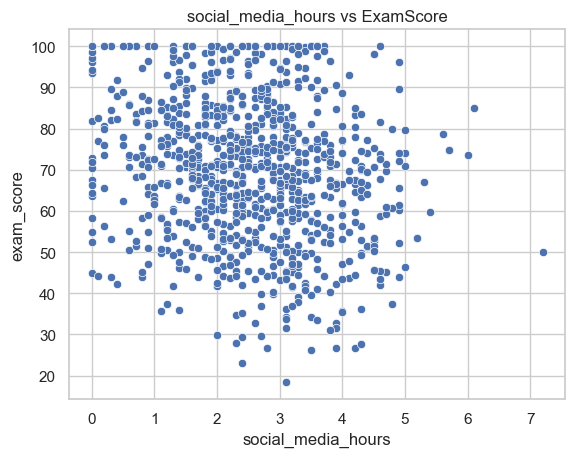

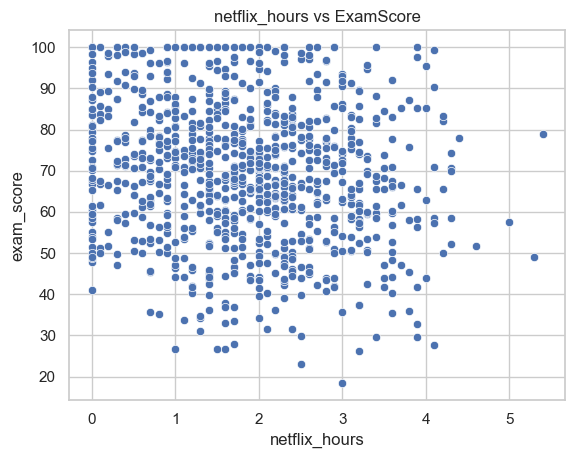

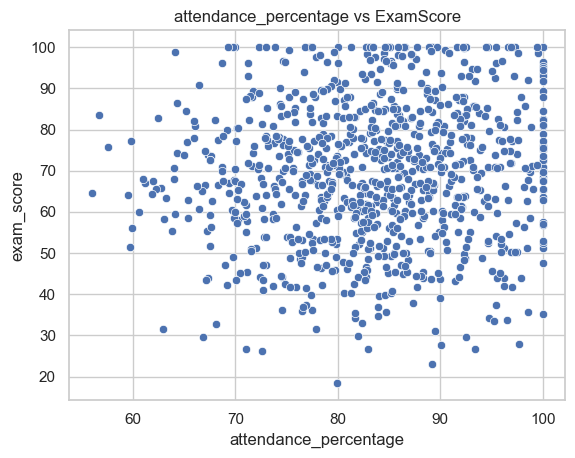

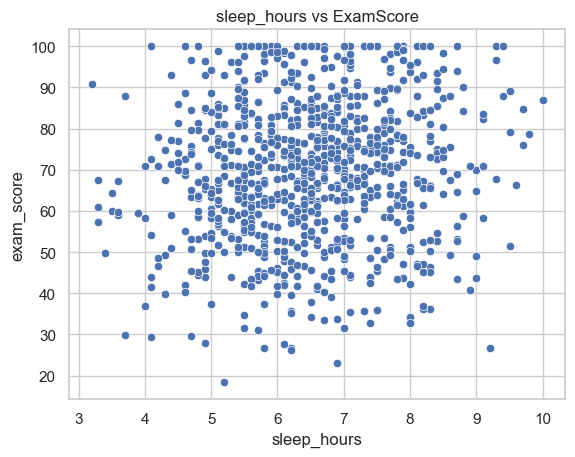

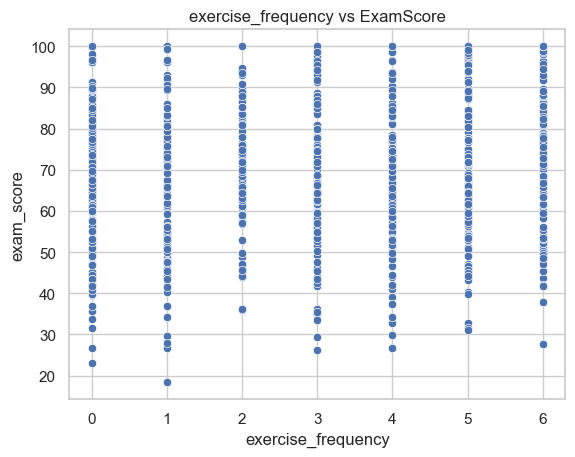

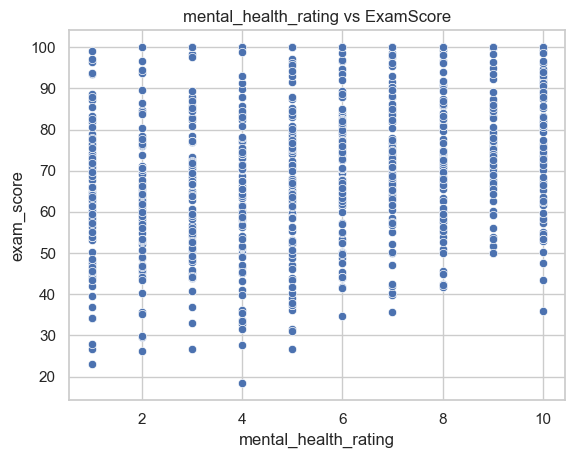

In [57]:
for feature in num_features:
    sns.scatterplot(data=df,x=feature,y="exam_score")
    plt.title(f"{feature} vs ExamScore")
    plt.show()
    

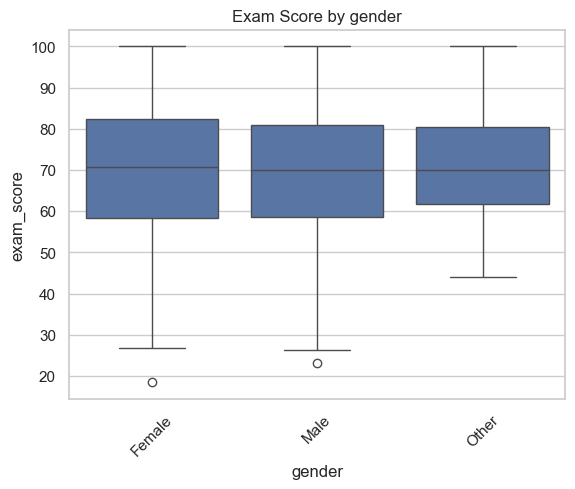

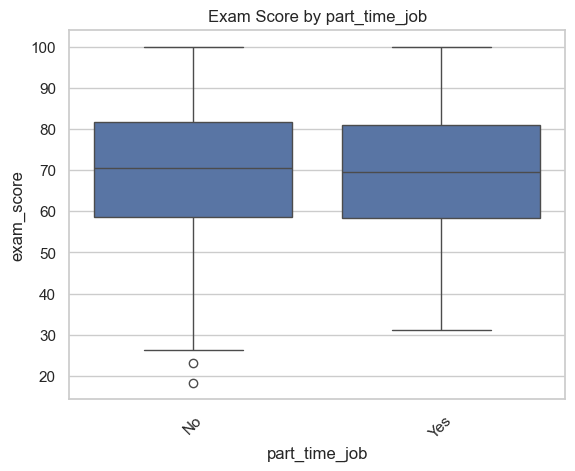

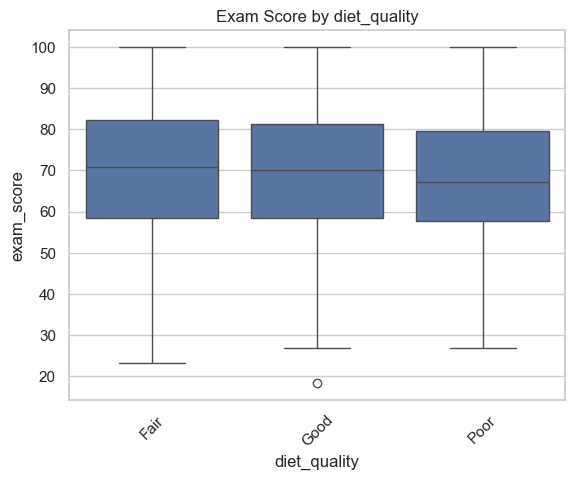

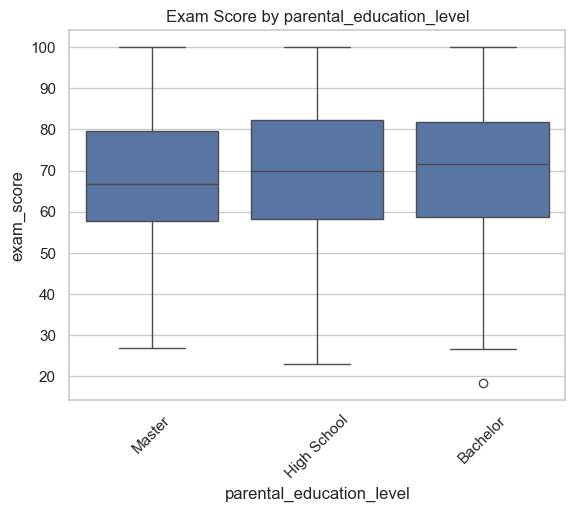

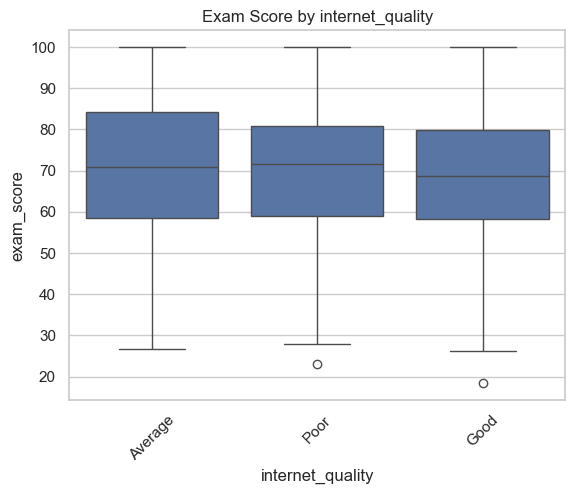

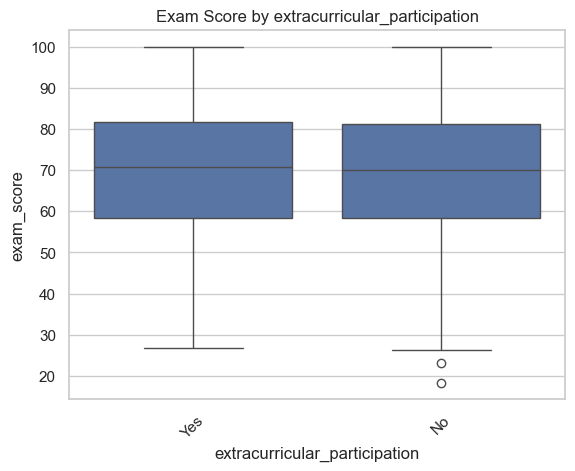

In [58]:
for col in categorical_cols:
    sns.boxplot(data=df,x=col,y="exam_score")
    plt.title(f"Exam Score by {col}")
    plt.xticks(rotation=45)
    plt.show()
    

In [59]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor


In [ ]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [61]:
df.head(2)

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0


In [62]:
features=["study_hours_per_day","attendance_percentage","mental_health_rating","sleep_hours","part_time_job"]

In [63]:
target="exam_score"

In [64]:
df_model=df[features+[target]].copy()

In [65]:
df_model

,study_hours_per_day,attendance_percentage,mental_health_rating,sleep_hours,part_time_job,exam_score
0,0.0,85.0,8,8.0,No,56.2
1,6.9,97.3,8,4.6,No,100.0
2,1.4,94.8,1,8.0,No,34.3
3,1.0,71.0,1,9.2,No,26.8
4,5.0,90.9,1,4.9,No,66.4
...,...,...,...,...,...,...
995,2.6,77.0,6,7.5,No,76.1
996,2.9,86.0,6,6.8,Yes,65.9
997,3.0,61.9,9,6.5,No,64.4
998,5.4,100.0,1,7.6,Yes,69.7


In [66]:
le=LabelEncoder()

In [68]:
df_model["part_time_job"]=le.fit_transform(df_model["part_time_job"])    

In [69]:
df_model

,study_hours_per_day,attendance_percentage,mental_health_rating,sleep_hours,part_time_job,exam_score
0,0.0,85.0,8,8.0,0,56.2
1,6.9,97.3,8,4.6,0,100.0
2,1.4,94.8,1,8.0,0,34.3
3,1.0,71.0,1,9.2,0,26.8
4,5.0,90.9,1,4.9,0,66.4
...,...,...,...,...,...,...
995,2.6,77.0,6,7.5,0,76.1
996,2.9,86.0,6,6.8,1,65.9
997,3.0,61.9,9,6.5,0,64.4
998,5.4,100.0,1,7.6,1,69.7


In [73]:
X= df_model[features]

In [71]:
y=df_model[target]

In [74]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2)

In [75]:
len(y_test)

182

In [76]:
len(y_train)

727

In [78]:
models={
    "LinearRegression":{
        "model" : LinearRegression(),
        "params" : {}
    },
    "DecisionTree" : {
        "model" : DecisionTreeRegressor(),
        "params": {"max_depth":[3,5,10],"min_samples_split": [2,5]}
    },
    "Randomforest":{
        "model": RandomForestRegressor(),
        "params":{ "n_estimators": [50,100],"max_depth": [5,10]}
    }
}

In [79]:
best_models =[]

In [82]:
for name,config in models.items():
    print(f"Training {name}")
    
    grid =GridSearchCV(config["model"],config["params"],cv=5,scoring="neg_mean_squared_error")
    grid.fit(X_train,y_train)
    
    y_pred=grid.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    
    r2=r2_score(y_test,y_pred)
    
    best_models.append({
        "model":name,
        "best_params": grid.best_params_,
        "rmse" :rmse,
        "r2":r2
    })

Training LinearRegression
Training DecisionTree
Training Randomforest


In [83]:
best_models

[{'model': 'LinearRegression',
  'best_params': {},
  'rmse': 7.201504796944671,
  'r2': 0.8269842915880196},
 {'model': 'DecisionTree',
  'best_params': {'max_depth': 5, 'min_samples_split': 5},
  'rmse': 8.672895876118789,
  'r2': 0.7490615035246179},
 {'model': 'Randomforest',
  'best_params': {'max_depth': 10, 'n_estimators': 100},
  'rmse': 7.816043646326164,
  'r2': 0.7961958709617032}]

In [87]:
results_df= pd.DataFrame(best_models)

In [89]:
results_df.sort_values(by="rmse")

,model,best_params,rmse,r2
0,LinearRegression,{},7.201505,0.826984
2,Randomforest,"{'max_depth': 10, 'n_estimators': 100}",7.816044,0.796196
1,DecisionTree,"{'max_depth': 5, 'min_samples_split': 5}",8.672896,0.749062


In [90]:
import joblib

best_row = results_df.sort_values(by="rmse").iloc[0]

In [91]:
best_row

model          LinearRegression
best_params                  {}
rmse                   7.201505
r2                     0.826984
Name: 0, dtype: object

In [92]:
best_model_name=best_row["model"]


In [93]:
best_model_name

'LinearRegression'

In [95]:
best_model_config= models[best_model_name]

In [96]:
best_model_config

{'model': LinearRegression(), 'params': {}}

In [97]:
final_model= best_model_config["model"]

In [99]:
final_model.fit(X,y)

LinearRegression()

In [101]:
joblib.dump(final_model,"best_model.pkl")

['best_model.pkl']

In [102]:
joblib.load("best_model.pkl").predict(X_test)

array([ 54.52840609,  57.67033365,  52.00021266,  88.24077353,
        63.04843369,  57.82131369,  76.46225033,  45.2446473 ,
        66.00468079,  67.04794846,  56.52867139,  94.31676369,
        53.98710733,  61.81291391,  82.57292072,  66.64007487,
        86.33867011,  59.41323383,  83.96961185,  71.57182983,
        57.99851846,  66.36405947,  80.61992577,  72.71447601,
        81.17073179,  62.39081909,  32.51965624,  81.86755532,
        45.97432955,  90.68772396,  44.72178483,  54.77872093,
        70.52672235,  65.10743322,  69.18028217,  91.99423492,
        50.4895758 ,  73.37721953,  76.68472104,  65.68154311,
        79.79071474,  48.01856192, 102.39790318,  68.15955942,
       100.79359858,  68.67625259,  89.92801771,  53.07774872,
        44.00956087,  72.25779551,  60.44639729,  76.75958523,
        60.28045582,  77.26666279,  76.501325  ,  89.1592608 ,
        40.85472813,  95.52324961,  57.60239563,  71.76290348,
        89.44570348,  57.48846515,  71.06624832,  58.60